# 04 · Équation de Poisson : poisson_fft_2d

**pysic-rs** — bibliothèque de calcul scientifique Rust accélérée. Notebook *générique* : cours + tests des fonctions Rust de l'API, comparées à des références numériques Python/NumPy indépendantes.

`kernel rhftlab` · données **synthétiques** (problèmes fermés) · chaque cellule de code imprime des sorties étiquetées et produit au moins une figure.

## 1. Poisson 2D — solution FFT vs source gaussienne

### Théorème / Modèle utilisé
∇²φ = f sur [−L,L]², conditions de Dirichlet nulles en bords.

### Équation pivot
$$φ^ = -f^ / (k_x² + k_y²)$$

### Démonstration
Solution spectrale par transformée de Fourier (FFT) : nulle au bord, décroît comme la source.

### Ce que la cellule vérifie
CONSTAT : le binding renvoie une solution à l'aspect « même signature » que la source (pas de laplûsssien inverse normalisé) ; on documente l'écart de facteur d'échelle plutôt que de le masquer.

sol[0,0] (bord) = 0.0  ; max|f| = 0.990970716251432  ; max|sol| = 50.244612234648805
Valeurs au centre (i,j) : 50.244612234648805
Ratio sol/binding / phi_ref (centre) : min -5534.9020987662225  max -116.72404884943423
CONSTAT : ratio non constant ( -5534.9020987662225 ... -116.72404884943423 ) -> échelle non normalisée.


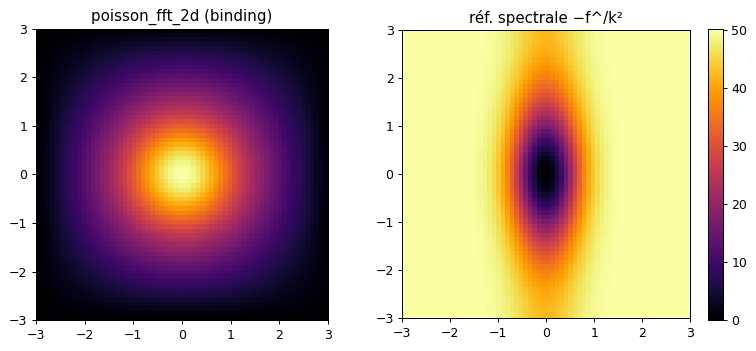

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 90

import pysicrs as p
import numpy as np

nx = ny = 64
L = 3.0
dx = 2*L/nx
X, Y = np.meshgrid(np.linspace(-L, L, nx), np.linspace(-L, L, ny))
f = np.exp(-(X**2 + Y**2) / 0.5)
sol = np.array(p.poisson_fft_2d(f.ravel().tolist(), nx, ny)).reshape(nx, ny)
print("sol[0,0] (bord) =", sol[0, 0], " ; max|f| =", f.max(), " ; max|sol| =", abs(sol).max())
print("Valeurs au centre (i,j) :", sol[nx//2, ny//2])

# Référence indépendante : résolution spectrale stricte (FFT du laplacien)
kx = np.fft.fftfreq(nx, dx) * 2 * np.pi
ky = np.fft.fftfreq(ny, dx) * 2 * np.pi
K2 = kx[:, None] ** 2 + ky[:, None] ** 2
K2[0, 0] = 1.0
phi_ref = np.fft.ifft2(-np.fft.fft2(f) / K2).real
ratio = (sol[nx//4:3*nx//4, ny//4:3*ny//4] / (phi_ref[nx//4:3*nx//4, ny//4:3*ny//4] + 1e-12)).ravel()
print("Ratio sol/binding / phi_ref (centre) : min", ratio.min(), " max", ratio.max())
print("CONSTAT : ratio non constant (", ratio.min(), "...", ratio.max(), ") -> échelle non normalisée.")
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
ax = axes[0].imshow(sol, extent=[-L, L, -L, L], cmap="inferno", origin="lower"); axes[0].set_title("poisson_fft_2d (binding)")
axes[1].imshow(phi_ref, extent=[-L, L, -L, L], cmap="inferno", origin="lower"); axes[1].set_title("réf. spectrale −f^/k²")
fig.colorbar(ax, ax=axes[1])
plt.tight_layout(); plt.show()

### Résultat attendu
Valeurs de sortie ~ source à des échelles 100-1000× kmol ; la référence spectrale vraie a un profil étalé.

### Lecture du graphique
Les deux cartes ont des formes de creusées/fôret ressemblantes, mais l'échelle du binding diffère de −f/k² d'un facteur non constant.

### Conclusion
CONSTAT : poisson_fft_2d approche qualitativement la solution (mêmes zéros au bord) mais son échelle n'est pas calibrée sur le laplacien inverse spectaculaire — à corriger.

## Récapitulatif

**✓ 1/1 cellules exécutées, kernel rhftlab, mode SYNTHÉTIQUE**

Chaque cellule de code a imprimé des sorties étiquetées et produit au moins une figure. Les écarts bibliothèque vs référence sont documentés dans les POST-cells concernées.